# ARIMA
Macro-only benchmark: Box-Jenkins ARIMA models use autoregressive lags, differencing, and moving-average terms to model persistent macroeconomic dynamics. In this project, ARIMA serves as a transparent classical baseline for GDP growth and inflation forecasts, allowing us to test whether text-enhanced TFT improves beyond a strong traditional time-series model. The ARIMA benchmark was used as an evaluation metric for the Laborda et al. project, listed below.

Reference: Box, G.; Jenkins, G.M. Time Series Analysis; Forecasting and Control; Holden-Day: San Francisco, CA, USA, 1970.

# Set-Up

In [198]:
!pip install pmdarima

In [199]:
import pandas as pd
from google.colab import drive
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from pmdarima import auto_arima


In [200]:
# set up mount to google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [201]:
# load data
# for now: only monthly data
path_monthly = "/content/drive/MyDrive/AML/macro-vars-monthly.csv"
df_monthly = pd.read_csv(path_monthly)
print(df_monthly.head(20))

    Unnamed: 0  CPI  PCEPI  PAYEMS  JTSJOL  UMCSENT  INDPRO
0   1919-01-01  NaN    NaN     NaN     NaN      NaN  4.8739
1   1919-02-01  NaN    NaN     NaN     NaN      NaN  4.6585
2   1919-03-01  NaN    NaN     NaN     NaN      NaN  4.5238
3   1919-04-01  NaN    NaN     NaN     NaN      NaN  4.6046
4   1919-05-01  NaN    NaN     NaN     NaN      NaN  4.6315
5   1919-06-01  NaN    NaN     NaN     NaN      NaN  4.9277
6   1919-07-01  NaN    NaN     NaN     NaN      NaN  5.2239
7   1919-08-01  NaN    NaN     NaN     NaN      NaN  5.3047
8   1919-09-01  NaN    NaN     NaN     NaN      NaN  5.1970
9   1919-10-01  NaN    NaN     NaN     NaN      NaN  5.1432
10  1919-11-01  NaN    NaN     NaN     NaN      NaN  5.0624
11  1919-12-01  NaN    NaN     NaN     NaN      NaN  5.1432
12  1920-01-01  NaN    NaN     NaN     NaN      NaN  5.6279
13  1920-02-01  NaN    NaN     NaN     NaN      NaN  5.6279
14  1920-03-01  NaN    NaN     NaN     NaN      NaN  5.5201
15  1920-04-01  NaN    NaN     NaN     N

In [202]:
df_monthly = df_monthly.rename(columns={'Unnamed: 0': 'Date'})

# set date as index
df_monthly = df_monthly.set_index('Date')

# drop finally data samples since we require full data for forecasting to compare forecast and test data for evaluation protocol
df_monthly.index = pd.to_datetime(df_monthly.index)
df_monthly = df_monthly.loc[df_monthly.index <= '2026-02-01']
df_monthly.index.freq = 'MS'
print(df_monthly.tail(20))

                CPI    PCEPI    PAYEMS  JTSJOL  UMCSENT    INDPRO
Date                                                             
2024-07-01  313.569  123.736  157748.0  7426.0     66.4   99.9757
2024-08-01  314.062  123.889  157757.0  7520.0     67.9  100.4309
2024-09-01  314.732  124.164  157912.0  6943.0     70.1   99.8084
2024-10-01  315.631  124.494  157945.0  7379.0     70.5   99.4695
2024-11-01  316.528  124.637  158079.0  7566.0     71.8   99.2925
2024-12-01  317.604  124.979  158316.0  7295.0     74.0  100.3273
2025-01-01  318.961  125.417  158268.0  7431.0     71.7  100.0647
2025-02-01  319.679  125.921  158310.0  7242.0     64.7  101.0993
2025-03-01  319.785  125.941  158377.0  6952.0     57.0  101.0404
2025-04-01  320.302  126.150  158485.0  7098.0     52.2  101.1279
2025-05-01  320.620  126.380  158498.0  7310.0     52.2  100.9655
2025-06-01  321.435  126.743  158478.0  7204.0     60.7  101.4785
2025-07-01  322.169  126.960  158542.0  7089.0     61.7  101.8940
2025-08-01

# Data Checks
## Only Monthly Variables for now
This means I can skip all alignment issues for now to get a first ARIMA running

## Stationarity

In [203]:
# first: stationarity? likely not with trend variables
adf_results = {}

for col in df_monthly.columns:
    # Drop NaNs for each specific column to avoid errors
    result = adfuller(df_monthly[col].dropna())

    # Store the p-value (index 1 of the result)
    adf_results[col] = result[1]

# Convert to a Series for a nice clean list
p_values = pd.Series(adf_results)

print("Stationary (= ok) if p<0.05")
print("ADF p-values per column:")
print(p_values)

Stationary (= ok) if p<0.05
ADF p-values per column:
CPI        1.000000
PCEPI      0.998265
PAYEMS     0.942872
JTSJOL     0.731566
UMCSENT    0.107747
INDPRO     0.972958
dtype: float64


In [204]:
log_cols = ['CPI', 'PCEPI', 'JTSJOL', 'PAYEMS', 'INDPRO']   # strictly positive, makes sense to log since want growth rate
diff_only = ['UMCSENT']           # difference without log

for col in log_cols:
    diff_series = np.log(df_monthly[col]).diff().dropna()
    pval = adfuller(diff_series)[1]
    print(f"{col} log+diff: p = {pval:.6f}")

for col in diff_only:
    diff_series = df_monthly[col].diff().dropna()
    pval = adfuller(diff_series)[1]
    print(f"{col} diff only: p = {pval:.6f}")
# looks good now

CPI log+diff: p = 0.000112
PCEPI log+diff: p = 0.039269
JTSJOL log+diff: p = 0.000109
PAYEMS log+diff: p = 0.000000
INDPRO log+diff: p = 0.000000
UMCSENT diff only: p = 0.000000


In [205]:
# get final data set
df_final = pd.DataFrame(index=df_monthly.index)

for col in log_cols:
    df_final[col] = np.log(df_monthly[col]).diff()

for col in diff_only:
    df_final[col] = df_monthly[col].diff()

#df_final.index = pd.to_datetime(df_final.index)
#df_final.index.freq = 'MS'  # MS = Month Start
print(df_final.tail(20))


                 CPI     PCEPI    JTSJOL    PAYEMS    INDPRO  UMCSENT
Date                                                                 
2024-07-01  0.001676  0.001593  0.001348  0.000336 -0.009143     -1.8
2024-08-01  0.001571  0.001236  0.012579  0.000057  0.004543      1.5
2024-09-01  0.002131  0.002217 -0.079832  0.000982 -0.006218      2.2
2024-10-01  0.002852  0.002654  0.060904  0.000209 -0.003401      0.4
2024-11-01  0.002838  0.001148  0.025026  0.000848 -0.001781      1.3
2024-12-01  0.003394  0.002740 -0.036475  0.001498  0.010368      2.2
2025-01-01  0.004264  0.003498  0.018471 -0.000303 -0.002621     -2.3
2025-02-01  0.002249  0.004011 -0.025763  0.000265  0.010286     -7.0
2025-03-01  0.000332  0.000159 -0.040868  0.000423 -0.000583     -7.7
2025-04-01  0.001615  0.001658  0.020784  0.000682  0.000866     -4.8
2025-05-01  0.000992  0.001822  0.029430  0.000082 -0.001607      0.0
2025-06-01  0.002539  0.002868 -0.014607 -0.000126  0.005068      8.5
2025-07-01  0.002281

## ARIMA: Pseudo-Forecasting

In [206]:
# set-up
n_forecast = 12  # how many periods to hold out, here for monthly variables
horizons = [1, 6, 12]
n_folds = 5
train = df_final.iloc[:-n_forecast]
test = df_final.iloc[-n_forecast:]

In [207]:
results = {}
forecasts = {}
conf_ints = {}

In [208]:
# --- Fit on train, forecast test period ---
for col in df_final.columns:
  model = SARIMAX(train[col].dropna(),
                  order=(1, 0, 1),
                  seasonal_order=(0, 0, 1, 12),
                  enforce_stationarity=False,
                  enforce_invertibility=False)
  results[col] = model.fit(disp=False)

  forecast = results[col].get_forecast(steps=n_forecast)
  forecasts[col] = forecast.predicted_mean
  conf_ints[col] = forecast.conf_int()

In [209]:
# --- Forecast errors ---
forecast_df = pd.DataFrame(forecasts, index=test.index)

mae = (forecast_df - test).abs().mean()
rmse = ((forecast_df - test) ** 2).mean() ** 0.5

print("MAE:\n", mae.round(4))
print("\nRMSE:\n", rmse.round(4))

# also: normalized RMSE (relative to std of test series)
# to account for fact that data differently scaled (log etc.)
nrmse = rmse / test.std()
print("Normalized RMSE:\n", nrmse.round(4))

MAE:
 CPI        0.0013
PCEPI      0.0009
JTSJOL     0.0364
PAYEMS     0.0005
INDPRO     0.0034
UMCSENT    3.3470
dtype: float64

RMSE:
 CPI        0.0015
PCEPI      0.0013
JTSJOL     0.0449
PAYEMS     0.0006
INDPRO     0.0039
UMCSENT    4.2827
dtype: float64
Normalized RMSE:
 CPI        1.5285
PCEPI      1.3616
JTSJOL     1.0096
PAYEMS     0.9448
INDPRO     1.1675
UMCSENT    1.0123
dtype: float64


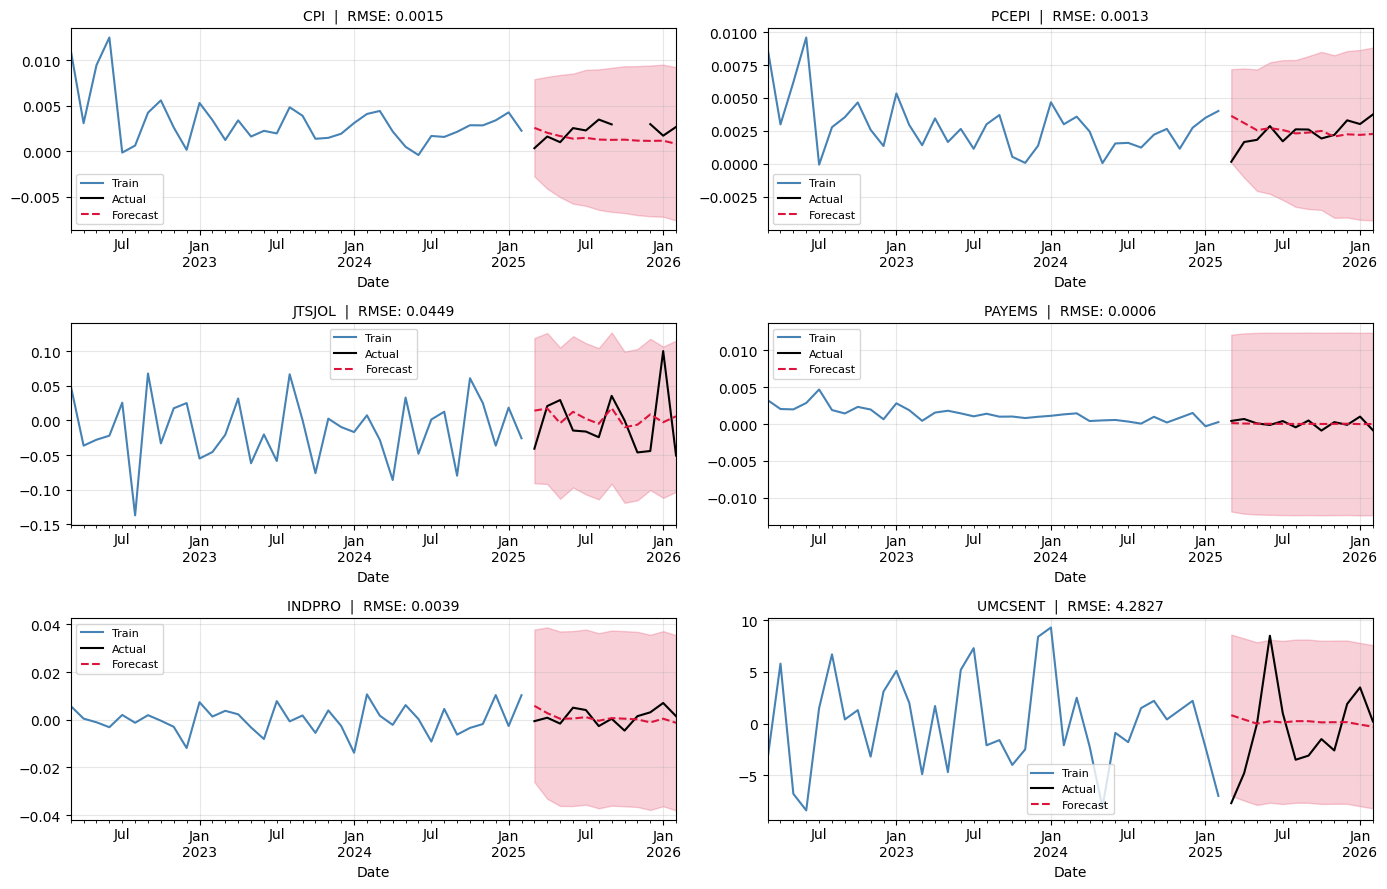

In [210]:
# --- Plots ---
n_cols = 2
n_rows = int(np.ceil(len(df_final.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(df_final.columns):
    ax = axes[i]

    # show last 36 months of training data for context
    train[col].iloc[-36:].plot(ax=ax, label='Train', color='steelblue')
    test[col].plot(ax=ax, label='Actual', color='black', linewidth=1.5)
    forecast_df[col].plot(ax=ax, label='Forecast', color='crimson', linestyle='--')

    # confidence interval
    ci = conf_ints[col]
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, color='crimson')

    ax.set_title(f"{col}  |  RMSE: {rmse[col]:.4f}", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Rolling Window Approach

In [211]:
def get_folds(df, n_folds, max_horizon=12):
  """Generate train/test splits, each test window = max_horizon months"""
  n = len(df)
  test_size = max_horizon
  # space folds evenly across the series
  # here, we luckily don't have to worry about data frequency since i am only using monthly data
  # for now!
  fold_ends = np.linspace(n - n_folds * test_size, n - test_size, n_folds, dtype=int)

  folds = []
  for end in fold_ends:
      train = df.iloc[:end]
      test = df.iloc[end:end + test_size]
      folds.append((train, test))
  return folds


def fit_and_forecast(train_series, horizon):
  train_series = train_series.dropna()
  model = SARIMAX(train_series,
                  order=(1, 0, 1),
                  seasonal_order=(0, 0, 1, 12),
                  enforce_stationarity=False,
                  enforce_invertibility=False)
  result = model.fit(maxiter = 250,
                     disp=False)
  forecast = result.get_forecast(steps=horizon)
  return forecast.predicted_mean


def compute_metrics(actual, predicted):
  errors = actual.values - predicted.values
  mae  = np.mean(np.abs(errors))
  rmse = np.sqrt(np.mean(errors ** 2))
  # mask zeros to avoid division issues in MAPE
  mask = actual.values != 0
  mape = np.mean(np.abs(errors[mask] / actual.values[mask])) * 100
  return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

# helper: since our data is often transformed, transform it back to calculate MAPE
def invert_transform(col, forecasted_diff, last_known_value, is_log=False):
    if is_log:
        last_log = np.log(last_known_value)
        return np.exp(last_log + forecasted_diff.cumsum())
    else:
        return last_known_value + forecasted_diff.cumsum()

In [212]:
folds_transformed = get_folds(df_final, n_folds=n_folds)
folds_original    = get_folds(df_monthly, n_folds=n_folds)

In [213]:
# --- Main CV loop ---
# results[col][horizon] = {MAE, RMSE, MAPE}
cv_results = {col: {h: [] for h in horizons} for col in df_final.columns}
cv_forecasts = {col: {h: [] for h in horizons} for col in df_final.columns}  # add this


for fold_i, ((train, test), (train_orig, test_orig)) in enumerate(zip(folds_transformed, folds_original)):
    print(f"Fold {fold_i+1}: train up to {train.index[-1].date()}, test {test.index[0].date()} → {test.index[-1].date()}")

    for col in df_final.columns:
        for h in horizons:
            forecast = fit_and_forecast(train[col], horizon=h)

            if col in log_cols:
                last_val        = train_orig[col].iloc[-1]
                forecast_levels = invert_transform(col, forecast, last_val, is_log=True)
                actual_levels   = test_orig[col].iloc[:h]
            elif col in diff_only:
                last_val        = train_orig[col].iloc[-1]
                forecast_levels = invert_transform(col, forecast, last_val, is_log=False)
                actual_levels   = test_orig[col].iloc[:h]
            else:  # already stationary, no transformation
                forecast_levels = forecast
                actual_levels   = test[col].iloc[:h]

            # drop NaNs in actual before computing metrics
            mask = actual_levels.notna()
            actual_clean   = actual_levels[mask]
            forecast_clean = forecast_levels[mask]

            if len(actual_clean) == 0:  # entire test window is NaN, skip
                continue

            # align forecast index to actual
            forecast_clean.index = actual_clean.index

            metrics = compute_metrics(actual_clean, forecast_clean)
            cv_results[col][h].append(metrics)
            cv_forecasts[col][h].append({   # store for plotting
                'forecast': forecast_clean,
                'actual':   actual_clean,
            })

Fold 1: train up to 2021-02-01, test 2021-03-01 → 2022-02-01
Fold 2: train up to 2022-02-01, test 2022-03-01 → 2023-02-01
Fold 3: train up to 2023-02-01, test 2023-03-01 → 2024-02-01
Fold 4: train up to 2024-02-01, test 2024-03-01 → 2025-02-01


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Fold 5: train up to 2025-02-01, test 2025-03-01 → 2026-02-01


In [214]:
# --- Aggregate: mean over folds ---
mean_levels = df_monthly.mean()

rows = []
for col in df_final.columns:
    for h in horizons:
        fold_metrics = cv_results[col][h]
        mean_rmse = np.mean([m["RMSE"] for m in fold_metrics])
        rows.append({
            "variable":   col,
            "horizon":    h,
            "mean_RMSE":  mean_rmse,
            "mean_MAE":   np.mean([m["MAE"]  for m in fold_metrics]),
            "mean_MAPE":  np.mean([m["MAPE"] for m in fold_metrics]),
            "NRMSE":      mean_rmse / mean_levels[col],  # normalized to account for diufferent scales of variables
        })

results_df = pd.DataFrame(rows)
print(results_df.pivot(index="variable", columns="horizon"))

           mean_RMSE                              mean_MAE              \
horizon           1            6            12          1           6    
variable                                                                 
CPI         0.853919     1.848902     3.010335    0.853919    1.657091   
INDPRO      1.232825     1.562498     1.846964    1.232825    1.495259   
JTSJOL    480.809727  1007.299948  1298.880275  480.809727  917.571174   
PAYEMS    260.977423  1003.893429  1752.168323  260.977423  903.611558   
PCEPI       0.297902     0.538596     0.754706    0.297902    0.490936   
UMCSENT     5.945831     7.730874     8.091592    5.945831    7.013488   

                      mean_MAPE                           NRMSE            \
horizon            12        1          6          12        1         6    
variable                                                                    
CPI          2.636703  0.291488   0.577807   0.912166  0.006871  0.014877   
INDPRO       1.740098  1.

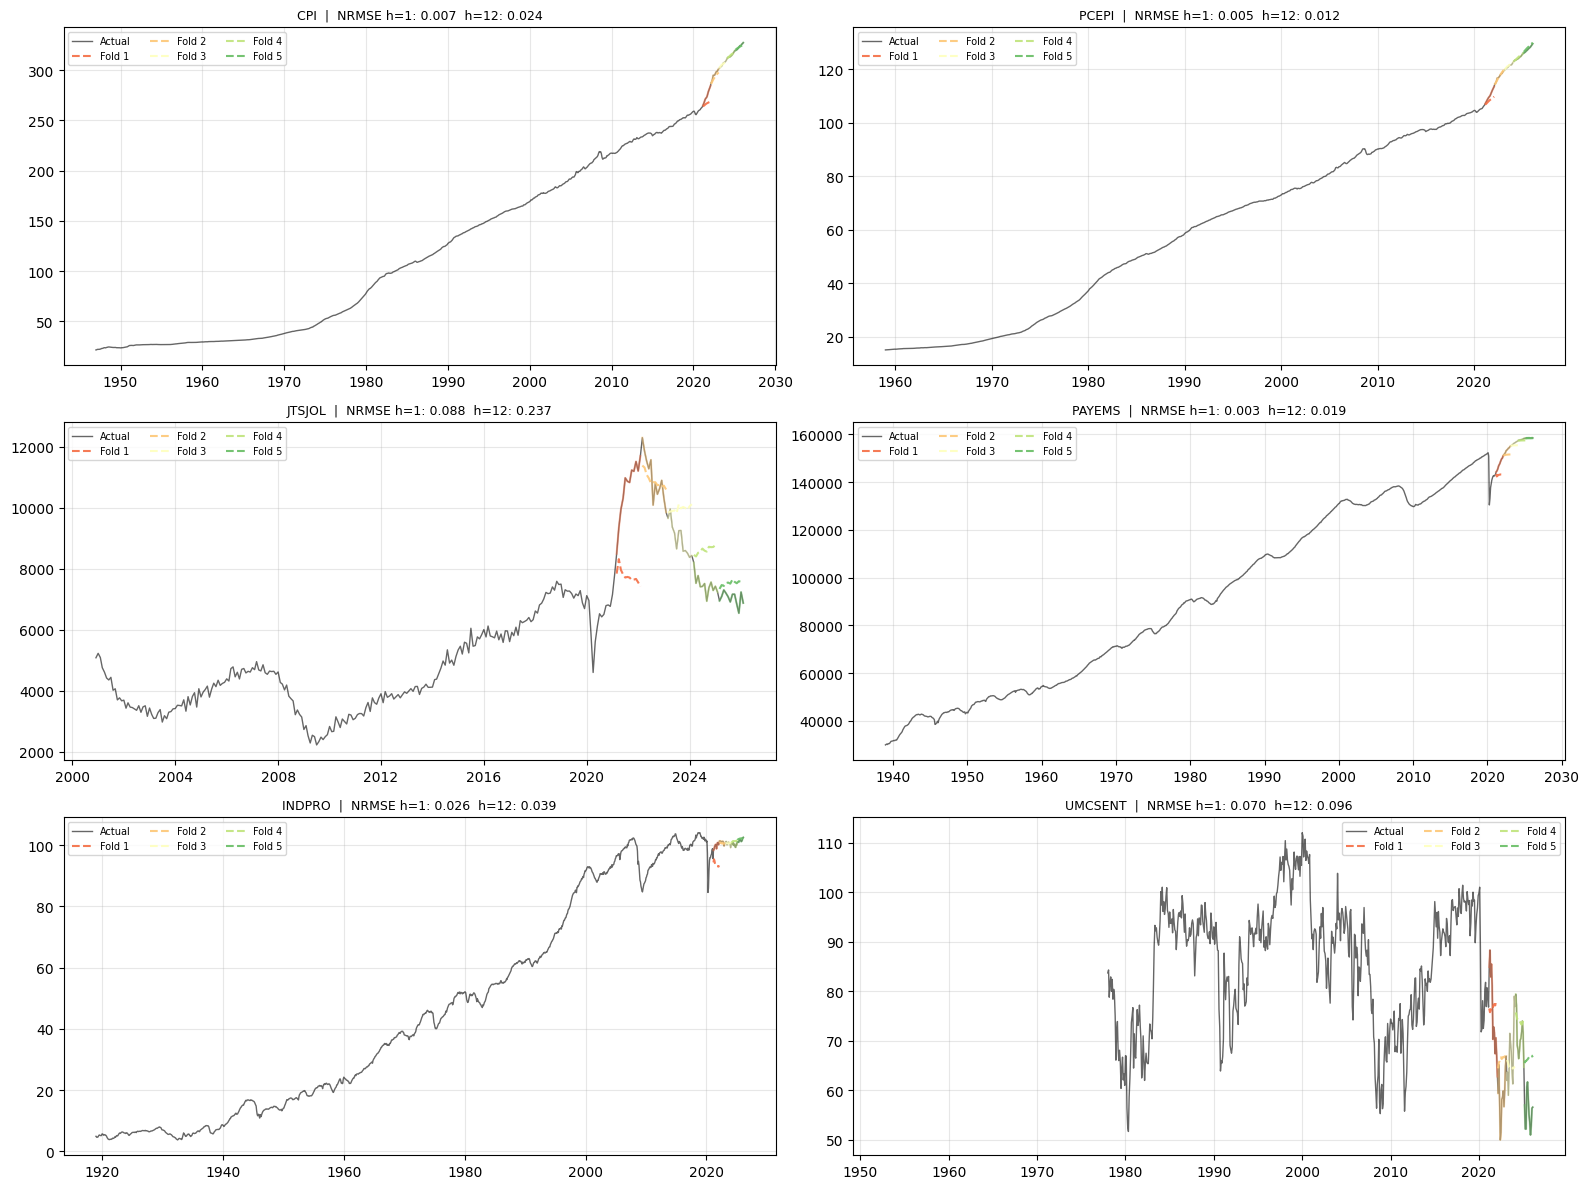

In [215]:
# add plots with folds overlayered
n_cols = 2
n_rows = int(np.ceil(len(df_final.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, n_folds))

for i, col in enumerate(df_final.columns):
    ax = axes[i]

    # plot full actual in background
    # in true dimensions, NOT in log space
    ax.plot(df_monthly[col].index, df_monthly[col].values,
        color='black', linewidth=1, label='Actual', alpha=0.6, zorder=2)

    # overlay h=12 forecast for each fold
    for fold_i, entry in enumerate(cv_forecasts[col][12]):
        ax.plot(entry['forecast'], color=colors[fold_i], linewidth=1.5,
                linestyle='--', alpha=0.9, label=f'Fold {fold_i+1}')
        ax.plot(entry['actual'], color=colors[fold_i], linewidth=1.5,
                alpha=0.5)

    # NRMSE in title
    nrmse_row = results_df[(results_df['variable'] == col)]
    nrmse_1   = nrmse_row[nrmse_row['horizon'] == 1]['NRMSE'].values
    nrmse_12  = nrmse_row[nrmse_row['horizon'] == 12]['NRMSE'].values
    title = f"{col}  |  NRMSE h=1: {nrmse_1[0]:.3f}  h=12: {nrmse_12[0]:.3f}" \
            if len(nrmse_1) and len(nrmse_12) else col
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, ncol=3)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Validation: Choosing the optimal ARIMA(p,d,q)

*   p = degree of autoregressivity
*   d = degree of integration => 0 for us since we manually use log differencing to keep track of data transformations for other models. This improves the computational speed of auto_arima (to find optimal (p,d,q) per variable) substantially!
*   q = degree of moving average


In [216]:
# train, validation, test split
# temporal dimension of course
n_test       = 24  # final test, never touch until end
n_validation = 24  # order selection

df_train_val = df_final.iloc[:-n_test]
df_test      = df_final.iloc[-n_test:]

df_train_val_orig = df_monthly.iloc[:-n_test]
df_test_orig      = df_monthly.iloc[-n_test:]

In [217]:
# order selection via auto_arima on train, evaluated on validation
best_orders = {}

for col in df_final.columns:
    train_series = df_train_val.iloc[:-n_validation][col].dropna()

    model = auto_arima(train_series,
                       seasonal=True, m=12,
                       stepwise=True,
                       information_criterion='aic',
                       max_p=3, max_q=3,
                       max_P=2, max_Q=2,
                       d=0, D=0, # already differenced manually
                       trace=False,
                       error_action='ignore',
                       suppress_warnings=True)

    best_orders[col] = {
        'order':          model.order,
        'seasonal_order': model.seasonal_order,
    }
    print(f"{col}: {model.order} x {model.seasonal_order}")

CPI: (1, 0, 0) x (1, 0, 0, 12)
PCEPI: (1, 0, 2) x (0, 0, 1, 12)
JTSJOL: (1, 0, 0) x (2, 0, 2, 12)
PAYEMS: (3, 0, 2) x (0, 0, 0, 12)
INDPRO: (2, 0, 0) x (1, 0, 1, 12)
UMCSENT: (1, 0, 2) x (1, 0, 1, 12)


In [218]:
# update functions from above
def get_folds(df, n_folds, max_horizon=12):
    """Generate train/test splits, each test window = max_horizon months"""
    n = len(df)
    test_size = max_horizon
    fold_ends = np.linspace(n - n_folds * test_size, n - test_size, n_folds, dtype=int)
    folds = []
    for end in fold_ends:
        train = df.iloc[:end]
        test  = df.iloc[end:end + test_size]
        folds.append((train, test))
    return folds


def fit_and_forecast(train_series, horizon, col):
    # drop if missing
    train_series = train_series.dropna()
    # use the best order that we determined before
    order          = best_orders[col]['order']
    seasonal_order = best_orders[col]['seasonal_order']

    model = SARIMAX(train_series,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    result = model.fit(maxiter=250, disp=False)
    forecast = result.get_forecast(steps=horizon)
    return forecast.predicted_mean


def compute_metrics(actual, predicted):
    errors = actual.values - predicted.values
    mae    = np.mean(np.abs(errors))
    rmse   = np.sqrt(np.mean(errors ** 2))
    mask   = actual.values != 0
    mape   = np.mean(np.abs(errors[mask] / actual.values[mask])) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


# to go back to original data value (so, before log differencing)
def invert_transform(col, forecasted_diff, last_known_value, is_log=False):
    if is_log:
        last_log = np.log(last_known_value)
        return np.exp(last_log + forecasted_diff.cumsum())
    else:
        return last_known_value + forecasted_diff.cumsum()


In [219]:
# run model on training data, NO test data
folds_transformed = get_folds(df_train_val,      n_folds=n_folds)
folds_original    = get_folds(df_train_val_orig, n_folds=n_folds)

cv_results   = {col: {h: [] for h in horizons} for col in df_final.columns}
cv_forecasts = {col: {h: [] for h in horizons} for col in df_final.columns}

for fold_i, ((train, test), (train_orig, test_orig)) in enumerate(zip(folds_transformed, folds_original)):
    print(f"Fold {fold_i+1}: train up to {train.index[-1].date()}, test {test.index[0].date()} → {test.index[-1].date()}")

    for col in df_final.columns:
        for h in horizons:
            forecast = fit_and_forecast(train[col], h, col)   # pass col

            if col in log_cols:
                last_val        = train_orig[col].iloc[-1]
                forecast_levels = invert_transform(col, forecast, last_val, is_log=True)
                actual_levels   = test_orig[col].iloc[:h]
            elif col in diff_only:
                last_val        = train_orig[col].iloc[-1]
                forecast_levels = invert_transform(col, forecast, last_val, is_log=False)
                actual_levels   = test_orig[col].iloc[:h]
            else:
                forecast_levels = forecast
                actual_levels   = test[col].iloc[:h]

            # ensure we drop NA values
            # especially relevant for CPI
            mask           = actual_levels.notna()
            actual_clean   = actual_levels[mask]
            forecast_clean = forecast_levels[mask]

            if len(actual_clean) == 0:
                continue

            forecast_clean.index = actual_clean.index
            metrics = compute_metrics(actual_clean, forecast_clean)
            # save results and forecasts for plots
            cv_results[col][h].append(metrics)
            cv_forecasts[col][h].append({'forecast': forecast_clean, 'actual': actual_clean})

Fold 1: train up to 2019-02-01, test 2019-03-01 → 2020-02-01


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fold 2: train up to 2020-02-01, test 2020-03-01 → 2021-02-01


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fold 3: train up to 2021-02-01, test 2021-03-01 → 2022-02-01
Fold 4: train up to 2022-02-01, test 2022-03-01 → 2023-02-01
Fold 5: train up to 2023-02-01, test 2023-03-01 → 2024-02-01


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [220]:
# aggregate over folds and print
mean_levels = df_monthly.mean()

rows = []
for col in df_final.columns:
    for h in horizons:
        fold_metrics = cv_results[col][h]

        if len(fold_metrics) == 0:  # skip if no metrics collected
            continue

        mean_rmse = np.mean([m["RMSE"] for m in fold_metrics])
        mean_mae  = np.mean([m["MAE"]  for m in fold_metrics])
        mean_mape = np.mean([m["MAPE"] for m in fold_metrics])

        rows.append({
            "variable":  col,
            "horizon":   h,
            "mean_RMSE": mean_rmse,
            "mean_MAE":  mean_mae,
            "mean_MAPE": mean_mape,
            "NRMSE":     mean_rmse / mean_levels[col],
        })

results_df_with_validation = pd.DataFrame(rows)

# --- Print pivot tables ---
print("With train-validation-test split:")
for metric in ["mean_RMSE", "mean_MAE", "mean_MAPE", "NRMSE"]:
    print(f"\n{metric}:")
    print(results_df_with_validation.pivot(index="variable", columns="horizon", values=metric).round(4))

With train-validation-test split:

mean_RMSE:
horizon         1          6          12
variable                                
CPI         0.7975     2.4853     4.9299
INDPRO      1.9141     3.5994     3.3516
JTSJOL    456.2474   915.9144  1028.4712
PAYEMS    558.9156  3827.0544  3978.3868
PCEPI       0.2866     0.5914     0.9862
UMCSENT     6.4683    10.2339     9.9549

mean_MAE:
horizon         1          6          12
variable                                
CPI         0.7975     2.1359     4.1468
INDPRO      1.9141     3.3126     3.0065
JTSJOL    456.2474   801.4566   903.1331
PAYEMS    558.9156  3452.0693  3635.1426
PCEPI       0.2866     0.5455     0.8501
UMCSENT     6.4683     9.5304     9.0698

mean_MAPE:
horizon       1        6        12
variable                          
CPI       0.2919   0.7697   1.4592
INDPRO    1.9456   3.5596   3.1424
JTSJOL    6.2306   9.6302   9.6679
PAYEMS    0.3751   2.5093   2.5634
PCEPI     0.2619   0.4987   0.7554
UMCSENT   8.1621  13.3240  12.

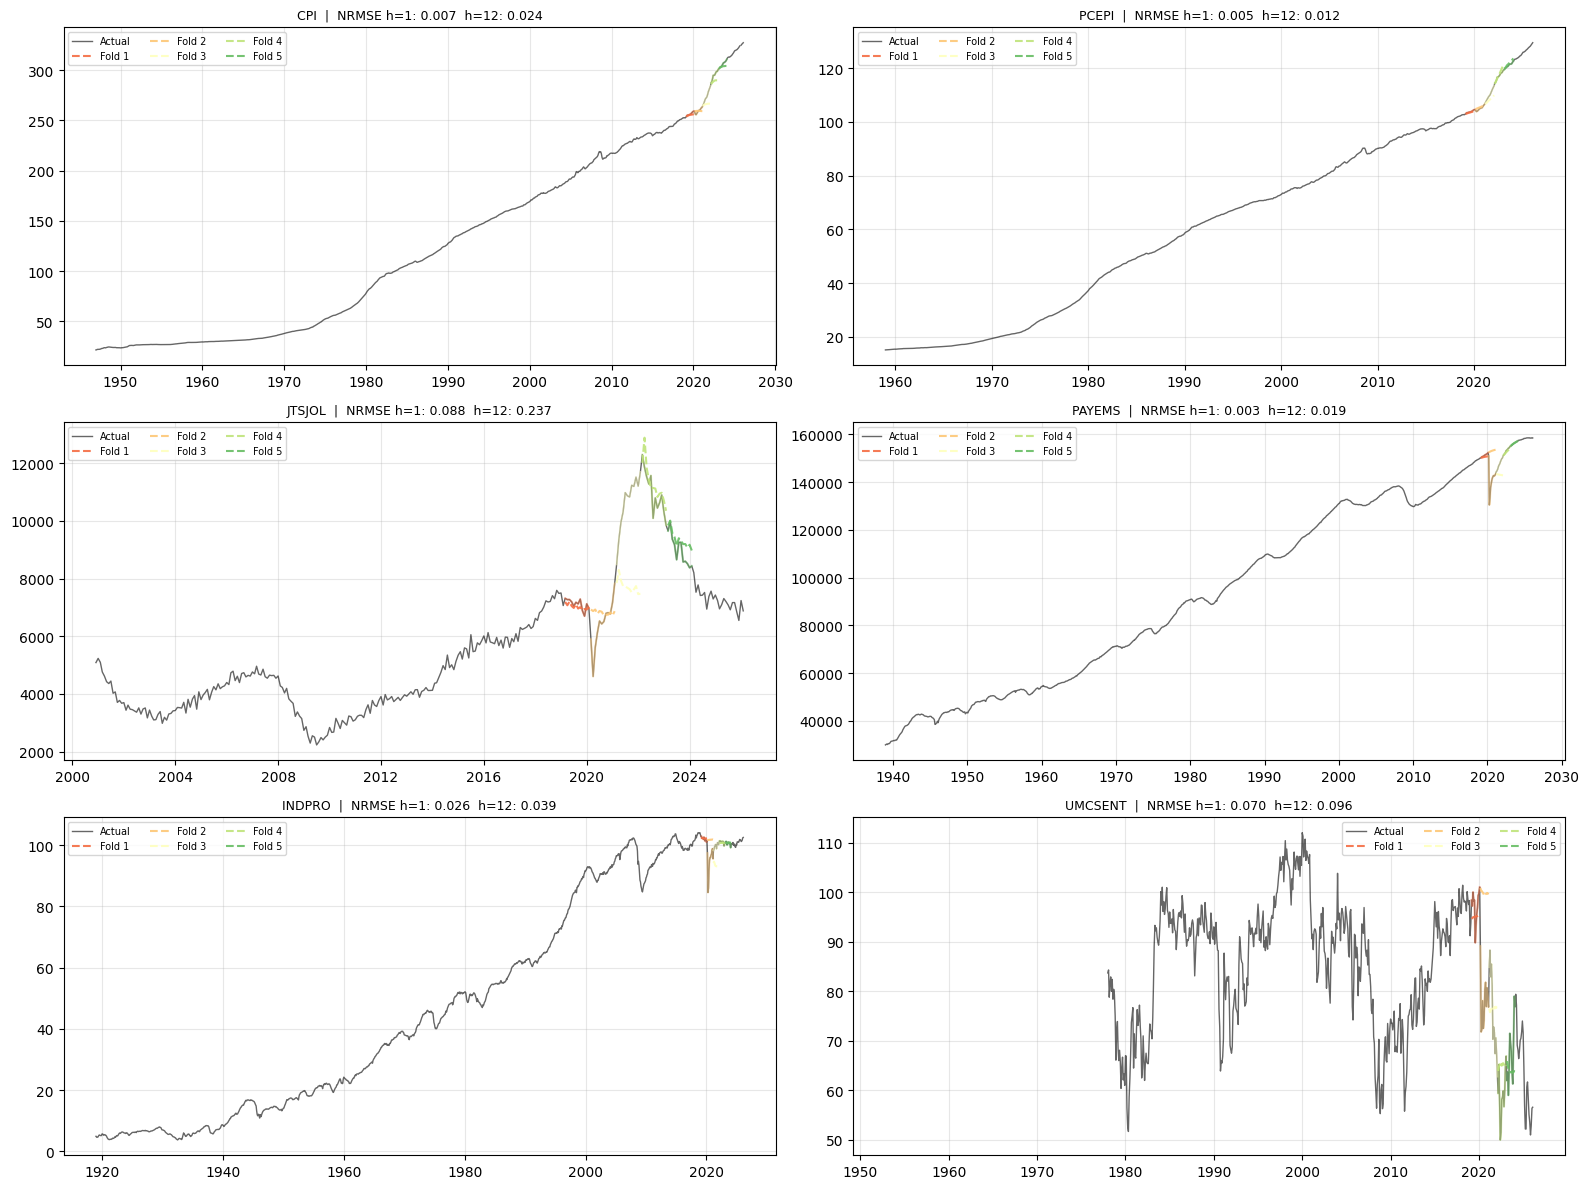

In [221]:
# add plots with folds overlayered
n_cols = 2
n_rows = int(np.ceil(len(df_final.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, n_folds))

for i, col in enumerate(df_final.columns):
    ax = axes[i]

    # plot full actual in background
    # in true dimensions, NOT in log space
    ax.plot(df_monthly[col].index, df_monthly[col].values,
        color='black', linewidth=1, label='Actual', alpha=0.6, zorder=2)

    # overlay h=12 forecast for each fold
    for fold_i, entry in enumerate(cv_forecasts[col][12]):
        ax.plot(entry['forecast'], color=colors[fold_i], linewidth=1.5,
                linestyle='--', alpha=0.9, label=f'Fold {fold_i+1}')
        ax.plot(entry['actual'], color=colors[fold_i], linewidth=1.5,
                alpha=0.5)

    # NRMSE in title
    nrmse_row = results_df[(results_df['variable'] == col)]
    nrmse_1   = nrmse_row[nrmse_row['horizon'] == 1]['NRMSE'].values
    nrmse_12  = nrmse_row[nrmse_row['horizon'] == 12]['NRMSE'].values
    title = f"{col}  |  NRMSE h=1: {nrmse_1[0]:.3f}  h=12: {nrmse_12[0]:.3f}" \
            if len(nrmse_1) and len(nrmse_12) else col
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, ncol=3)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()